# ILUSTR 2 — R² nie wykrywa złego modelu; χ² radzi sobie z niepewnością pomiarów

Dwa osobne zjawiska, oba na tym samym mechanizmie: **liczba podsumowująca dopasowanie
nie zastępuje patrzenia na wykres**.

1. **R² może być wysokie nawet przy źle dobranym modelu** — pokazujemy to na dokładnie
   tych samych dwóch przykładach, co konspekt (Przykład 1: model trafiony, Przykład 2:
   dane $e^x$ dopasowane wielomianem 2. stopnia) — i patrzymy na **reszty**, które R²
   ukrywa.
2. **χ² (dopasowanie ważone)** pozwala uwzględnić, że nie wszystkie punkty pomiarowe są
   tak samo wiarygodne — pokazujemy, jak jeden zaszumiony punkt (outlier) potrafi
   „przeciągnąć" zwykłe (nieważone) dopasowanie, i jak wagi $1/\sigma_i^2$ temu
   zapobiegają.

## 1. R² wysokie przy dobrym MODELU (Przykład 1)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def R2(y, y_hat):
    """Wspolczynnik determinacji R^2 = SS_reg / SS_tot = 1 - SS_res/SS_tot.
    Uzywamy postaci 1 - SS_res/SS_tot -- rownowaznej matematycznie, ale numerycznie
    bezpieczniejszej (nie wymaga, zeby SS_reg + SS_res dokladnie sumowaly sie do SS_tot
    w arytmetyce zmiennoprzecinkowej)."""
    y = np.asarray(y, dtype=float)
    y_hat = np.asarray(y_hat, dtype=float)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot

# Przyklad 1 z konspektu: model kwadratowy, dane faktycznie kwadratowe + szum
x1 = np.array([1.0, 2.0, 3.0, 4.0])
y1 = np.array([1.1, 4.2, 8.8, 16.6])
p1 = np.polyfit(x1, y1, deg=2)
y1_hat = np.polyval(p1, x1)
r2_1 = R2(y1, y1_hat)

# Przyklad 2: dane naprawde wykladnicze e^x, dopasowywane (celowo zlym) modelem
# kwadratowym -- dokladnie tak, jak w konspekcie ("czego nie widac po formalizmie").
rng = np.random.default_rng(1)
x2 = np.linspace(0, 3, 20)
y2 = np.exp(x2) + rng.normal(0, 0.3, size=x2.shape)  # prawdziwa zaleznosc: e^x + szum
p2 = np.polyfit(x2, y2, deg=2)  # ZLY model -- wielomian 2. stopnia do danych e^x
y2_hat = np.polyval(p2, x2)
r2_2 = R2(y2, y2_hat)

print(f"R^2, Przyklad 1 (model trafiony):     {r2_1:.4f}")
print(f"R^2, Przyklad 2 (model ZLE dobrany):   {r2_2:.4f}  -- prawie tak samo wysokie!")

R^2, Przyklad 1 (model trafiony):     0.9989
R^2, Przyklad 2 (model ZLE dobrany):   0.9911  -- prawie tak samo wysokie!


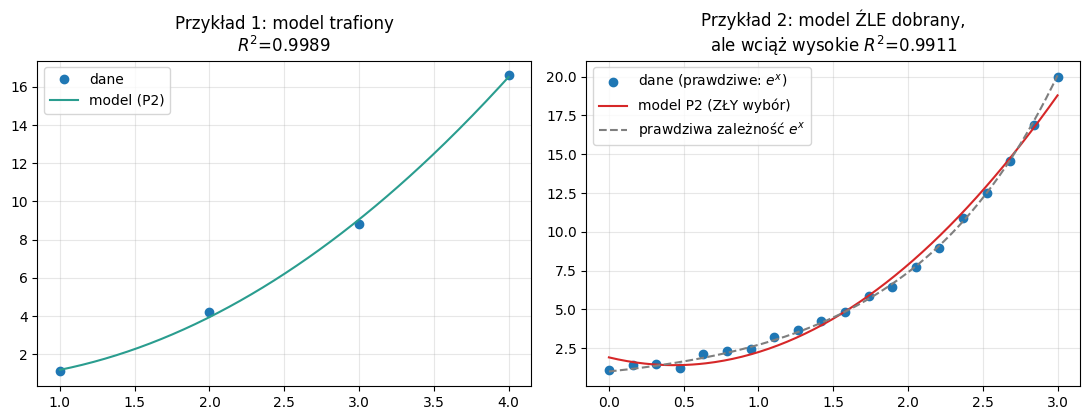

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

xx1 = np.linspace(x1.min(), x1.max(), 200)
axes[0].plot(x1, y1, "o", color="#1f77b4", label="dane")
axes[0].plot(xx1, np.polyval(p1, xx1), color="#2a9d8f", label="model (P2)")
axes[0].set_title(f"Przykład 1: model trafiony\n$R^2$={r2_1:.4f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

xx2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(x2, y2, "o", color="#1f77b4", label="dane (prawdziwe: $e^x$)")
axes[1].plot(xx2, np.polyval(p2, xx2), color="#d62728", label="model P2 (ZŁY wybór)")
axes[1].plot(xx2, np.exp(xx2), "--", color="#7f7f7f", label="prawdziwa zależność $e^x$")
axes[1].set_title(f"Przykład 2: model ŹLE dobrany,\nale wciąż wysokie $R^2$={r2_2:.4f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


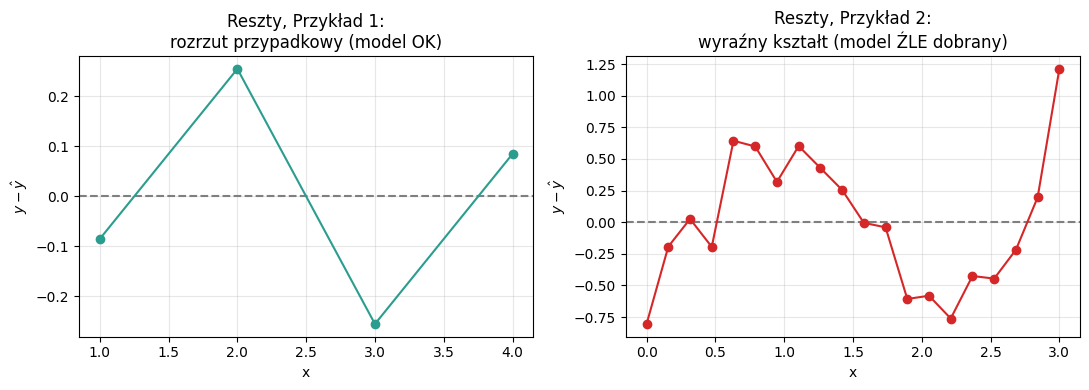

W prawym panelu reszty NIE sa przypadkowe, ukladaja sie w wyrazny ksztalt -- to jest sygnal zlego modelu, ktorego samo R^2 nie ujawnia.


In [3]:
# To, czego R^2 NIE pokazuje, widac dopiero na wykresie reszt (y - y_hat kontra x):
# przypadkowy rozrzut = model dobry; wyrazny KSZTALT w resztach = model zly, nawet
# jesli R^2 jest wysokie.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
resid1 = y1 - y1_hat
resid2 = y2 - y2_hat

axes[0].axhline(0, color="#7f7f7f", ls="--")
axes[0].plot(x1, resid1, "o-", color="#2a9d8f")
axes[0].set_title("Reszty, Przykład 1:\nrozrzut przypadkowy (model OK)")
axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$y-\hat y$")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="#7f7f7f", ls="--")
axes[1].plot(x2, resid2, "o-", color="#d62728")
axes[1].set_title("Reszty, Przykład 2:\nwyraźny kształt (model ŹLE dobrany)")
axes[1].set_xlabel("x"); axes[1].set_ylabel(r"$y-\hat y$")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()
print("W prawym panelu reszty NIE sa przypadkowe, ukladaja sie w",
      "wyrazny ksztalt -- to jest sygnal zlego modelu, ktorego samo R^2 nie ujawnia.")

## 2. Geometria R²: $SS_{tot}$, $SS_{reg}$

$R^2=SS_{reg}/SS_{tot}$ — stosunek „ile rozrzutu danych względem średniej wyjaśnia
model" do „ile rozrzutu jest w ogóle". Narysujmy oba składniki na Przykładzie 1.

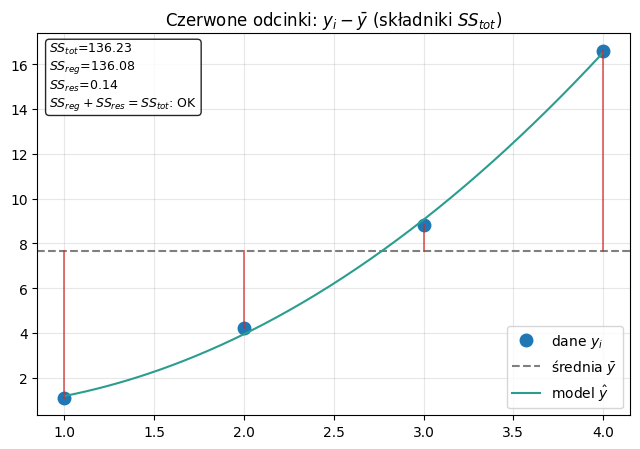

In [4]:
ybar = np.mean(y1)
SS_tot = np.sum((y1 - ybar) ** 2)
SS_reg = np.sum((y1_hat - ybar) ** 2)
SS_res = np.sum((y1 - y1_hat) ** 2)
assert np.isclose(SS_reg + SS_res, SS_tot)

fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.plot(x1, y1, "o", ms=9, color="#1f77b4", label="dane $y_i$")
ax.axhline(ybar, color="#7f7f7f", ls="--", label=r"średnia $\bar y$")
ax.plot(xx1, np.polyval(p1, xx1), color="#2a9d8f", label=r"model $\hat y$")
for xi, yi in zip(x1, y1):
    ax.plot([xi, xi], [ybar, yi], color="#d62728", lw=1.3, alpha=0.7)  # SS_tot: y-ybar
ax.text(0.02, 0.98, f"$SS_{{tot}}$={SS_tot:.2f}\n$SS_{{reg}}$={SS_reg:.2f}\n$SS_{{res}}$={SS_res:.2f}\n$SS_{{reg}}+SS_{{res}}=SS_{{tot}}$: OK",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))
ax.set_title(r"Czerwone odcinki: $y_i-\bar y$ (składniki $SS_{tot}$)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 3. Miara χ² i dopasowanie ważone przy niepewnym pomiarze (outlier)

Jeśli wiemy, że różne punkty pomiarowe mają różną niepewność $\sigma_i$, zwykłe (nieważone)
dopasowanie MNK traktuje je jednakowo — jeden „zły" punkt o dużym błędzie potrafi
przeciągnąć całą dopasowaną prostą/wielomian w swoją stronę. Dopasowanie **ważone**
($\chi^2=\sum_i\big((y_i-\hat y_i)/\sigma_i\big)^2$, wagi $w_i=1/\sigma_i^2$) daje mniej
wpływu punktom o dużej niepewności.

In [5]:
rng = np.random.default_rng(7)
n = 12
x3 = np.linspace(0, 10, n)
sigma = np.full(n, 0.5)          # typowa niepewnosc pomiaru dla wiekszosci punktow
y3_true = 2.0 * x3 + 1.0          # prawdziwa zaleznosc: prosta
y3 = y3_true + rng.normal(0, sigma)

# Dorzucmy JEDEN outlier -- punkt o duzej niepewnosci pomiarowej (np. zle dzialajacy
# czujnik przy jednym pomiarze), znaczaco odchylony od prawdziwej prostej
idx_outlier = 3
sigma[idx_outlier] = 8.0
y3[idx_outlier] = y3_true[idx_outlier] + 25.0  # duzy, ale ZGODNY z jego dużym sigma blad

def dopasuj_wazone(x, y, w=None, deg=1):
    """Wazona regresja wielomianowa stopnia 'deg'. Bez wag (w=None) to zwykle MNK.
    Realizacja: przeskalowanie kazdego wiersza ukladu Phi p = y przez sqrt(w_i) --
    dokladnie odpowiada minimalizacji Sum w_i*(y_i - model(x_i))^2."""
    Phi = np.column_stack([x**k for k in range(deg, -1, -1)])
    if w is None:
        w = np.ones_like(x)
    sw = np.sqrt(w)
    A = Phi * sw[:, None]
    b = y * sw
    p, *_ = np.linalg.lstsq(A, b, rcond=None)
    return p

w = 1.0 / sigma**2
p_niewazone = dopasuj_wazone(x3, y3, w=None, deg=1)
p_wazone = dopasuj_wazone(x3, y3, w=w, deg=1)
print("Dopasowanie gotowe -- porownanie ponizej na wykresach.")

Dopasowanie gotowe -- porownanie ponizej na wykresach.


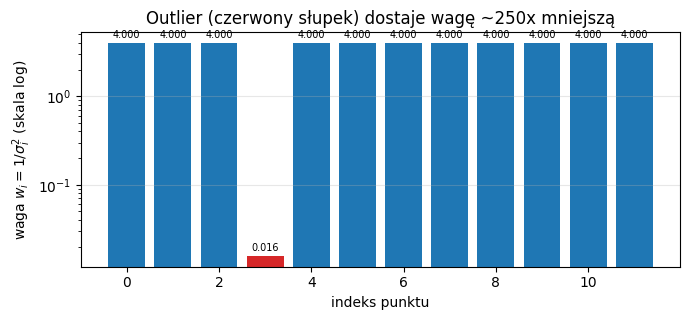

In [6]:
# Zanim zobaczymy dopasowanie, zobaczmy same WAGI: outlier (czerwony) dostaje wage o
# DWA RZEDY WIELKOSCI mniejsza niz reszta punktow -- skala logarytmiczna, bo na
# liniowej ten slupek bylby wizualnie niewidoczny (~0.016 kontra ~4.0).
fig, ax = plt.subplots(figsize=(7, 3.3))
colors = ["#d62728" if i == idx_outlier else "#1f77b4" for i in range(n)]
bars = ax.bar(range(n), w, color=colors)
ax.set_yscale("log")
ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)
ax.set_xlabel("indeks punktu"); ax.set_ylabel(r"waga $w_i=1/\sigma_i^2$ (skala log)")
ax.set_title("Outlier (czerwony słupek) dostaje wagę ~250x mniejszą")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


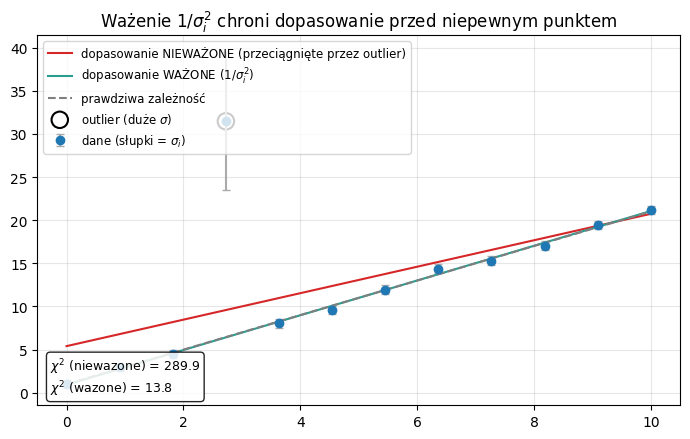

In [7]:
chi2_niewazone = np.sum(((y3 - np.polyval(p_niewazone, x3)) / sigma) ** 2)
chi2_wazone = np.sum(((y3 - np.polyval(p_wazone, x3)) / sigma) ** 2)
assert chi2_wazone < chi2_niewazone

fig, ax = plt.subplots(figsize=(7, 4.5))
xx3 = np.linspace(0, 10, 200)
ax.errorbar(x3, y3, yerr=sigma, fmt="o", color="#1f77b4", ecolor="#aaaaaa",
            capsize=3, label=r"dane (słupki = $\sigma_i$)")
ax.plot(xx3, np.polyval(p_niewazone, xx3), color="#d62728",
        label="dopasowanie NIEWAŻONE (przeciągnięte przez outlier)")
ax.plot(xx3, np.polyval(p_wazone, xx3), color="#2a9d8f",
        label=r"dopasowanie WAŻONE ($1/\sigma_i^2$)")
ax.plot(xx3, 2.0 * xx3 + 1.0, "--", color="#7f7f7f", label="prawdziwa zależność")
ax.scatter([x3[idx_outlier]], [y3[idx_outlier]], s=140, facecolors="none",
           edgecolors="black", linewidths=1.5, label=r"outlier (duże $\sigma$)")
ax.text(0.02, 0.02, f"$\chi^2$ (niewazone) = {chi2_niewazone:.1f}\n$\chi^2$ (wazone) = {chi2_wazone:.1f}",
        transform=ax.transAxes, va="bottom", ha="left", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(alpha=0.3)
ax.set_title(r"Ważenie $1/\sigma_i^2$ chroni dopasowanie przed niepewnym punktem")
fig.tight_layout()
plt.show()


## Najważniejsze wnioski

- Wysokie $R^2$ **nie dowodzi**, że model jest właściwie dobrany — pokazuje tylko, że
  model dobrze podąża za konkretnymi danymi, na których go dopasowano. Wykres reszt
  ujawnia problem, który sam $R^2$ ukrywa: przypadkowy rozrzut oznacza dobry model,
  wyraźny kształt reszt oznacza zły model.
- $R^2=SS_{reg}/SS_{tot}$ — geometrycznie: ile z rozrzutu danych względem średniej
  „wyjaśnia" model, w stosunku do całego rozrzutu.
- Miara $\chi^2$ i dopasowanie ważone ($w_i=1/\sigma_i^2$) pozwalają uwzględnić różną
  wiarygodność punktów pomiarowych — punkt o dużej niepewności dostaje małą wagę i
  przestaje przeciągać dopasowanie w swoją stronę.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.polyfit(x, y, deg)` | Nieważona regresja wielomianowa MNK |
| `np.linalg.lstsq(A, b)` | Ogólne rozwiązanie najmniejszych kwadratów — tu użyte do zaimplementowania wagi przez przeskalowanie wierszy układu |
| `plt.errorbar(...)` / `plt.bar(...)` | Wykres punktów ze słupkami niepewności $\sigma_i$ / wykres słupkowy wag |

## ĆWICZENIE

1. Zmień Przykład 2 tak, żeby dane pochodziły z innej „złej" zależności (np.
   `y2 = np.log(x2 + 1)`) dopasowywanej wielomianem 2. stopnia — czy wykres reszt nadal
   ujawnia zły model, mimo wysokiego R²?
2. Dodaj **drugi** outlier do przykładu z sekcji 3 (inny punkt, też z dużym `sigma`) i
   sprawdź na wykresie wag, jak zmienia się rozkład wag i dopasowanie ważone.
3. **Rozszerzenie**: policz $\chi^2/(n-K)$ (tzw. zredukowane $\chi^2$, gdzie $K$ to liczba
   parametrów modelu) dla dopasowania ważonego z sekcji 3. Wartość bliska 1 oznacza, że
   przyjęte $\sigma_i$ dobrze opisują rzeczywisty rozrzut danych — sprawdź, czy tak jest
   tutaj.